In [ ]:
print("ok")

In [1]:
%pwd

'c:\\Users\\USER\\Desktop\\nova_pay_transactions'

In [4]:
import os

In [66]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
                classification_report,
                confusion_matrix,
                roc_auc_score,
                average_precision_score,
                precision_recall_curve
)
from sklearn.preprocessing import StandardScaler

In [12]:
DATA_PATH = "nova_pay_transcations (1).csv"

df = pd.read_csv(DATA_PATH)

In [22]:
df.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,...,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [16]:
print("Dataset shape:", df.shape)

Dataset shape: (10200, 26)


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             10200 non-null  str    
 1   customer_id                10200 non-null  str    
 2   timestamp                  10171 non-null  str    
 3   home_country               10200 non-null  str    
 4   source_currency            10200 non-null  str    
 5   dest_currency              10200 non-null  str    
 6   channel                    10200 non-null  str    
 7   amount_src                 10200 non-null  str    
 8   amount_usd                 9895 non-null   float64
 9   fee                        9905 non-null   float64
 10  exchange_rate_src_to_dest  10200 non-null  float64
 11  device_id                  10200 non-null  str    
 12  new_device                 10200 non-null  bool   
 13  ip_address                 9895 non-null   str    
 14  i

In [15]:
df.describe()

,amount_usd,fee,exchange_rate_src_to_dest,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
count,9895.000000,9905.000000,10200.000000,10200.000000,10200.000000,9905.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000,10200.000000
mean,410.973958,110.915958,151.070118,0.355567,422.387353,0.684846,0.002549,0.241320,0.131471,0.232255,0.042412,0.019314
std,1428.534323,1013.983451,360.401932,0.230242,339.577111,0.254493,0.052334,0.103254,0.950315,0.981683,0.083074,0.137632
min,7.230000,-1.000000,0.592000,0.004000,4.000000,-0.100000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000
25%,88.260000,2.310000,1.000000,0.200000,257.000000,0.522000,0.000000,0.166000,0.000000,0.000000,0.000000,0.000000
50%,151.890000,3.330000,7.142857,0.308000,298.000000,0.779000,0.000000,0.223000,0.000000,0.000000,0.000000,0.000000
75%,267.935000,5.040000,61.666667,0.440000,718.000000,0.923000,0.000000,0.332000,0.000000,0.000000,0.000000,0.000000
max,12498.570000,9999.990000,1388.888889,1.200000,1092.000000,0.971000,2.000000,0.554000,8.000000,9.000000,0.250000,1.000000


In [17]:
df.isna().sum()

transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [23]:
df.channel.value_counts()

channel
mobile       5908
web          3085
ATM           908
mobille        60
 mobile        48
MOBILE         47
unknown        37
WEB            36
 web           34
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

In [24]:
df.kyc_tier.value_counts()

kyc_tier
standard       7401
enhanced       1715
low             483
standrd          72
STANDARD         70
 standard        65
unknown          32
 enhanced        17
ENHANCED         17
enhancd          12
 low              8
LOW               5
 nan              2
NAN               1
Name: count, dtype: int64

In [31]:
df["timestamp"].value_counts()

timestamp
0000-00-00T00:00:00Z                21
2025/13/40 25:61:00                 11
2022-10-09 20:21:25.468549+00:00     2
2022-10-13 03:17:46.468549+00:00     2
2022-10-23 16:36:46.468549+00:00     2
                                    ..
2025-10-02 05:43:54.468549+00:00     1
2025-10-02 07:17:39.468549+00:00     1
2025-10-02 08:45:19.468549+00:00     1
2025-10-02 08:47:14.468549+00:00     1
2025-10-02 08:55:52.468549+00:00     1
Name: count, Length: 9941, dtype: int64

In [36]:
df["amount_src"].value_counts()

amount_src
102.29    5
115.29    4
54.74     4
82.25     4
261.23    4
         ..
37.0      1
199.31    1
108.83    1
229.13    1
130.78    1
Name: count, Length: 8801, dtype: int64

In [26]:
# Function to Perform Basic cleaning 

def clean_value(val, field):
    if pd.isna(val):
        return np.nan
    
    s = str(val).strip().lower()
    if s in {"", "nan"}:
        return np.nan

    if field == "channel":
        mapping = {
            "web": "web",
            "weeb": "web",
            "mobile": "mobile",
            "mobille": "mobile",
            "atm": "atm",
            "unknown": "unknown",
        }
        return mapping.get(s, s)

    if field == "kyc_tier":
        mapping = {
            "standard": "standard",
            "standrd": "standard",
            "enhanced": "enhanced",
            "enhancd": "enhanced",
            "low": "low",
            "unknown": "unknown",
        }
        return mapping.get(s, s)

    return s.upper()

In [ ]:
# Get a copy of the original dataframe to work on
work = df.copy()

In [42]:
for col in ["home_country", "source_currency", "dest_currency", "ip_country"]:
    if col in work.columns:
        work[col] = work[col].apply(lambda x: clean_value(x, col))

for col in ["channel", "kyc_tier"]:
    if col in work.columns:
        work[col] = work[col].apply(lambda x: clean_value(x, col))

if "amount_src" in work.columns:
    work["amount_src"] = pd.to_numeric(work["amount_src"], errors="coerce")

if "timestamp" in work.columns:
    work["timestamp"] = pd.to_datetime(work["timestamp"], errors="coerce", utc=True)

missing_summary = work.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

amount_to_prev_avg_ratio        419
ip_address                      305
amount_usd                      305
fee_to_amount_ratio             305
ip_country                      304
kyc_tier                        303
fee                             295
device_trust_score              295
customer_prev_avg_amount_usd    120
time_since_prev_txn_hours       115
timestamp                        61
amount_src                        4
dtype: int64

In [39]:
# Time-based and behavioral feature engineering
median_ts = work["timestamp"].dropna().sort_values().iloc[len(work["timestamp"].dropna()) // 2]
work["timestamp_missing"] = work["timestamp"].isna().astype(int)
work["timestamp_filled"] = work["timestamp"].fillna(median_ts)

In [41]:
# Sort by customer and time so historical features only use past transactions
work = work.sort_values(["customer_id", "timestamp_filled", "transaction_id"]).reset_index(drop=True)

ts = work["timestamp_filled"]
work["hour"] = ts.dt.hour
work["dayofweek"] = ts.dt.dayofweek
work["is_weekend"] = ts.dt.dayofweek.isin([5, 6]).astype(int)
work["month"] = ts.dt.month
work["days_since_start"] = (ts - ts.min()).dt.total_seconds() / 86400

grp = work.groupby("customer_id", sort=False)
work["customer_prev_txn_count"] = grp.cumcount()
work["customer_prev_avg_amount_usd"] = grp["amount_usd"].transform(lambda s: s.shift().expanding().mean())
work["time_since_prev_txn_hours"] = grp["timestamp_filled"].diff().dt.total_seconds() / 3600

work["amount_to_prev_avg_ratio"] = work["amount_usd"] / work["customer_prev_avg_amount_usd"]
work["fee_to_amount_ratio"] = work["fee"] / work["amount_usd"]
work["is_cross_border"] = (work["home_country"] != work["ip_country"]).astype(int)
work["currency_mismatch"] = (work["source_currency"] != work["dest_currency"]).astype(int)

# Final sort for time-based train/test split
work = work.sort_values("timestamp_filled").reset_index(drop=True)

work.head()

,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,...,is_weekend,month,days_since_start,customer_prev_txn_count,customer_prev_avg_amount_usd,time_since_prev_txn_hours,amount_to_prev_avg_ratio,fee_to_amount_ratio,is_cross_border,currency_mismatch
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,atm,278.19,278.19,4.25,...,0,10,0.000000,0,NaN,NaN,NaN,0.015277,0,1
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,...,0,10,0.082396,0,NaN,NaN,NaN,0.027481,0,1
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,...,0,10,0.181759,0,NaN,NaN,NaN,0.016840,0,1
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,...,0,10,0.269375,0,NaN,NaN,NaN,0.037367,0,1
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,...,0,10,0.620880,0,NaN,NaN,NaN,0.017964,0,1


In [45]:
# Checking for Class imbalance
work.is_fraud.value_counts()

is_fraud
0    10003
1      197
Name: count, dtype: int64

In [47]:
# Concise EDA summary tables

summary_table = pd.DataFrame({
    "metric": [
        "rows",
        "fraud_rate",
        "median_amount_usd_nonfraud",
        "median_amount_usd_fraud",
        "median_ip_risk_nonfraud",
        "median_ip_risk_fraud",
        "median_account_age_nonfraud",
        "median_account_age_fraud"
    ],
    "value": [
        len(work),
        round(work["is_fraud"].mean(), 4),
        work.loc[work["is_fraud"] == 0, "amount_usd"].median(),
        work.loc[work["is_fraud"] == 1, "amount_usd"].median(),
        work.loc[work["is_fraud"] == 0, "ip_risk_score"].median(),
        work.loc[work["is_fraud"] == 1, "ip_risk_score"].median(),
        work.loc[work["is_fraud"] == 0, "account_age_days"].median(),
        work.loc[work["is_fraud"] == 1, "account_age_days"].median(),
    ]
})

fraud_by_channel = work.groupby("channel", dropna=False)["is_fraud"].mean().sort_values(ascending=False)
fraud_by_kyc = work.groupby("kyc_tier", dropna=False)["is_fraud"].mean().sort_values(ascending=False)
fraud_by_loc = work.groupby("location_mismatch")["is_fraud"].mean()

In [49]:
display(summary_table)

,metric,value
0,rows,10200.0000
1,fraud_rate,0.0193
2,median_amount_usd_nonfraud,151.3800
3,median_amount_usd_fraud,184.4200
4,median_ip_risk_nonfraud,0.3080
5,median_ip_risk_fraud,0.3360
6,median_account_age_nonfraud,298.0000
7,median_account_age_fraud,147.0000


In [50]:
display(fraud_by_channel.rename("fraud_rate").to_frame())

,fraud_rate
channel,
unknown,0.027027
web,0.026109
mobile,0.016493
atm,0.014115


In [51]:
display(fraud_by_kyc.rename("fraud_rate").to_frame())

,fraud_rate
kyc_tier,
low,0.034274
unknown,0.031250
NaN,0.026403
standard,0.021556
enhanced,0.003975


In [52]:
display(fraud_by_loc.rename("fraud_rate").to_frame())

,fraud_rate
location_mismatch,
False,0.017205
True,0.035264


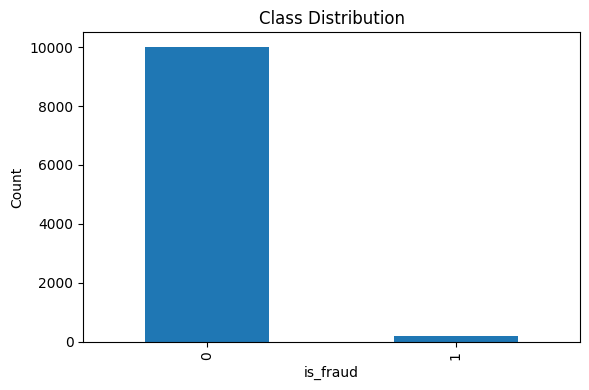

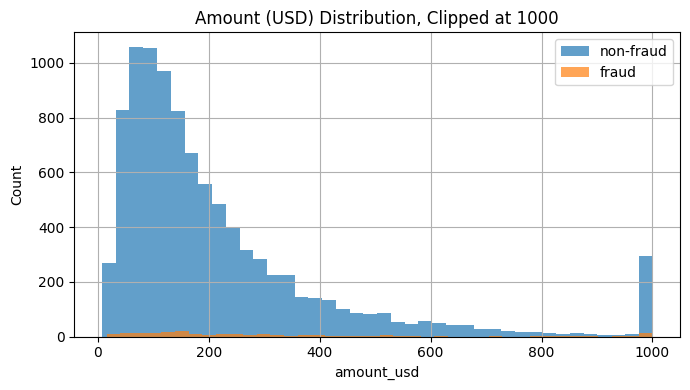

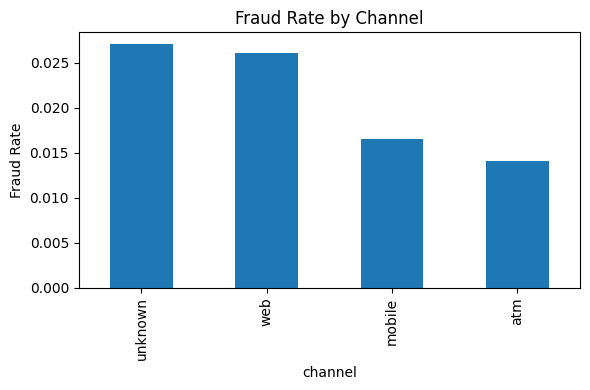

In [53]:
# EDA plots

plt.figure(figsize=(6, 4))
work["is_fraud"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("is_fraud")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
work.loc[work["is_fraud"] == 0, "amount_usd"].dropna().clip(upper=1000).hist(bins=40, alpha=0.7, label="non-fraud")
work.loc[work["is_fraud"] == 1, "amount_usd"].dropna().clip(upper=1000).hist(bins=40, alpha=0.7, label="fraud")
plt.title("Amount (USD) Distribution, Clipped at 1000")
plt.xlabel("amount_usd")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
fraud_by_channel.plot(kind="bar")
plt.title("Fraud Rate by Channel")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

In [54]:
# Feature set for modeling

feature_cols = [
    "home_country", "source_currency", "dest_currency", "channel",
    "new_device", "location_mismatch", "ip_risk_score", "kyc_tier",
    "account_age_days", "device_trust_score", "chargeback_history_count",
    "risk_score_internal", "txn_velocity_1h", "txn_velocity_24h",
    "corridor_risk", "amount_src", "amount_usd", "fee",
    "exchange_rate_src_to_dest", "timestamp_missing", "hour",
    "dayofweek", "is_weekend", "month", "days_since_start",
    "customer_prev_txn_count", "customer_prev_avg_amount_usd",
    "time_since_prev_txn_hours", "amount_to_prev_avg_ratio",
    "fee_to_amount_ratio", "is_cross_border", "currency_mismatch"
]


In [55]:
model_df = work[feature_cols + ["is_fraud"]].copy()

In [56]:
# Fill missing values
for col in model_df.select_dtypes(include="number").columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in model_df.select_dtypes(include="object").columns:
    model_df[col] = model_df[col].fillna("missing")

C:\Users\USER\AppData\Local\Temp\ipykernel_11508\945441972.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in model_df.select_dtypes(include="object").columns:


In [57]:
# One-hot encode categoricals
X = pd.get_dummies(model_df.drop(columns="is_fraud"), drop_first=False)
y = model_df["is_fraud"]

In [58]:
# Chronological split: first 80% train, last 20% test
split_idx = int(len(model_df) * 0.8)
X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

In [61]:
# Standardization using StandardScaler
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include="number").columns

scaler.fit(X_train[num_cols])
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [63]:
# Train model
model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [64]:
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))
print()
print(classification_report(y_test, pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, proba):.3f}")
print(f"PR-AUC: {average_precision_score(y_test, proba):.3f}")

Confusion Matrix:
[[1367  644]
 [   7   22]]

              precision    recall  f1-score   support

           0      0.995     0.680     0.808      2011
           1      0.033     0.759     0.063        29

    accuracy                          0.681      2040
   macro avg      0.514     0.719     0.435      2040
weighted avg      0.981     0.681     0.797      2040

ROC-AUC: 0.741
PR-AUC: 0.125


In [65]:
# Feature importance / interpretation using logistic regression coefficients

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_[0]
})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

top_positive = coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative = coef_df.sort_values("coefficient", ascending=True).head(10)

print("Top positive fraud indicators:")
display(top_positive)

print("Top negative fraud indicators:")
display(top_negative)

Top positive fraud indicators:


,feature,coefficient,abs_coefficient
48,kyc_tier_low,1.258020,1.258020
51,kyc_tier_unknown,1.086376,1.086376
32,source_currency_GBP,1.026275,1.026275
30,home_country_US,0.893952,0.893952
35,dest_currency_CNY,0.655884,0.655884
37,dest_currency_GBP,0.545213,0.545213
46,channel_web,0.490630,0.490630
39,dest_currency_MXN,0.420113,0.420113
36,dest_currency_EUR,0.402938,0.402938
9,corridor_risk,0.402500,0.402500


Top negative fraud indicators:


,feature,coefficient,abs_coefficient
47,kyc_tier_enhanced,-2.106585,2.106585
40,dest_currency_NGN,-1.583900,1.583900
33,source_currency_USD,-1.149696,1.149696
28,home_country_UK,-0.659000,0.659000
45,channel_unknown,-0.616269,0.616269
29,home_country_UNKNOWN,-0.494183,0.494183
0,new_device,-0.407704,0.407704
3,account_age_days,-0.378071,0.378071
5,chargeback_history_count,-0.289106,0.289106
49,kyc_tier_missing,-0.243075,0.243075


In [67]:
# Save the model
joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [68]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']